<a href="https://colab.research.google.com/github/joelhrtl/DataAnalysis/blob/main/Final_Project_DS_RSB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Market Price Forecast Analysis
Team Members:
1) Gonzalo Castro Ortiz
2) Xinyu YANG
3) An-Chun Liu
4) Emilio Cardenas García
5) Joel Hurtado León

Github: https://github.com/joelhrtl/Data-Science-/tree/main


This script performs a complete Machine Learning project for house price prediction, following the specified steps:

1.  **Import Libraries**
2.  **Load Dataset**
3.  **Initial Data Exploration**
4.  **Data Cleaning and Preparation**
5.  **Variable Definition (X and y)**
6.  **Data Splitting (Training/Testing)**
7.  **Model Training (Linear Regression and Random Forest)**
8.  **Model Evaluation**
9.  **Visualizations**
10. **Feature Importance (Random Forest)**
11. **Example Prediction**

In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Load the CSV file

Please upload the `HOUSE PRICES_csv.csv` file to your Colab environment. You can drag and drop the file into the Colab file panel (folder icon on the left) or use the following code to upload it.

In [ ]:
from google.colab import files

print("Please upload the file 'HOUSE PRICES_csv.csv'")
uploaded = files.upload()

df = None
for fn in uploaded.keys():
  print('File uploaded: "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
  try:
      df = pd.read_csv(fn)
      print("Dataset loaded successfully.")
  except Exception as e:
      print(f"Error reading file {fn}: {e}")

if df is None:
    print("Error: Could not load the dataset. Make sure you have uploaded the correct file.")

Please upload the file 'HOUSE PRICES_csv.csv'


Saving HOUSE PRICES_csv.csv to HOUSE PRICES_csv (1).csv
File uploaded: "HOUSE PRICES_csv (1).csv" with length 457311 bytes
Dataset loaded successfully.


### 3. Display initial dataset exploration

In [ ]:
if df is not None:
    # Display the first 5 rows
    print("\n--- First 5 rows of the dataset ---")
    display(df.head())

    # Display general information about the dataset (data types, non-null values)
    print("\n--- Dataset Information ---")
    df.info()

    # Display descriptive statistics for numerical columns
    print("\n--- Descriptive Statistics of the dataset ---")
    display(df.describe())

    # Check for null values
    print("\n--- Null values per column ---")
    display(df.isnull().sum())


--- First 5 rows of the dataset ---


,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price,Address
0,"79,545.45857",5.7,7.0,4.09,"23,087","1,059,033.6","208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,"79,248.64245",6.0,6.7,3.09,"40,173","1,505,890.9","188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,"61,287.06718",5.9,8.5,5.13,"36,882","1,058,988.0","9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,"63,345.24005",7.2,5.6,3.26,"34,310","1,260,616.8",USS Barnett\nFPO AP 44820
4,"59,982.19723",5.0,7.8,4.23,"26,354","630,943.5",USNS Raymond\nFPO AE 09386



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4548 entries, 0 to 4547
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Avg. Area Income    4548 non-null   object 
 1   House Age           4548 non-null   float64
 2   Number of Rooms     4548 non-null   float64
 3   Number of Bedrooms  4548 non-null   float64
 4   Area Population     4548 non-null   object 
 5   Price               4548 non-null   object 
 6   Address             4548 non-null   object 
dtypes: float64(3), object(4)
memory usage: 248.8+ KB

--- Descriptive Statistics of the dataset ---


,House Age,Number of Rooms,Number of Bedrooms
count,4548.000000,4548.000000,4548.000000
mean,5.978738,6.987995,3.981693
std,0.991525,1.007053,1.230939
min,2.600000,3.200000,2.000000
25%,5.300000,6.300000,3.140000
50%,6.000000,7.000000,4.050000
75%,6.700000,7.700000,4.490000
max,9.500000,10.800000,6.500000



--- Null values per column ---


,0
Avg. Area Income,0
House Age,0
Number of Rooms,0
Number of Bedrooms,0
Area Population,0
Price,0
Address,0


### 4. Clean data if necessary and remove the 'Address' column

In this step, we ensure there are no significant null values and remove irrelevant columns for the model.

In [ ]:
if df is not None:
    # Remove the 'Address' column as it will not be used for the model
    if 'Address' in df.columns:
        df = df.drop('Address', axis=1)
        print("Column 'Address' removed.")
    else:
        print("Column 'Address' not found.")

    # Convert numeric columns that are 'object' type to numeric
    columns_to_convert = ['Avg. Area Income', 'Area Population', 'Price']
    for col in columns_to_convert:
        if col in df.columns and df[col].dtype == 'object':
            # Remove commas and spaces, then convert to numeric
            df[col] = df[col].astype(str).str.replace(',', '').str.strip()
            # Use pd.to_numeric with errors='coerce' to handle potential non-numeric values
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"Column '{col}' converted to numeric.")

    # Handle potential nulls introduced by conversion (if errors='coerce' was used)
    if df.isnull().sum().sum() > 0:
        print("Warning: Null values found after cleaning or conversion. Consider handling them.")
        print(df.isnull().sum())
        # Optional: Fill nulls with mean or median if appropriate
        # for col in columns_to_convert:
        #     if df[col].isnull().any():
        #         df[col] = df[col].fillna(df[col].mean())
        #         print(f"Nulls in '{col}' filled with mean.")
    else:
        print("No null values found after cleaning and conversion.")

    print("Dataset ready for variable definition.")

Column 'Address' removed.
Column 'Avg. Area Income' converted to numeric.
Column 'Area Population' converted to numeric.
Column 'Price' converted to numeric.
No null values found after cleaning and conversion.
Dataset ready for variable definition.


### 5. Define X (independent variables) and y (target variable)

In [ ]:
if df is not None:
    # Define independent variables (features)
    X = df[['Avg. Area Income', 'House Age', 'Number of Rooms', 'Number of Bedrooms', 'Area Population']]

    # Define dependent variable (target)
    y = df['Price']

    print("X and y variables defined successfully.")
    print(f"Dimensions of X: {X.shape}")
    print(f"Dimensions of y: {y.shape}")

X and y variables defined successfully.
Dimensions of X: (4548, 5)
Dimensions of y: (4548,)


### 6. Split data into training and testing sets

In [ ]:
if df is not None:
    # Split data into training and test sets (80% training, 20% test)
    # random_state ensures reproducible results
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data split into training and test sets.")
    print(f"Training set size (X_train): {X_train.shape}")
    print(f"Test set size (X_test): {X_test.shape}")
    print(f"Training target size (y_train): {y_train.shape}")
    print(f"Test target size (y_test): {y_test.shape}")

Data split into training and test sets.
Training set size (X_train): (3638, 5)
Test set size (X_test): (910, 5)
Training target size (y_train): (3638,)
Test target size (y_test): (910,)


### 7. Train two Machine Learning models

We will train a Linear Regression model and a Random Forest Regressor.

In [ ]:
if df is not None:
    # Model 1: Linear Regression
    print("\n--- Training Linear Regression Model ---")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    print("Linear Regression Model trained.")

    # Model 2: Random Forest Regressor
    print("\n--- Training Random Forest Regressor Model ---")
    # We use a reasonable number of estimators (n_estimators) and a random_state for reproducibility
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor Model trained.")


--- Training Linear Regression Model ---
Linear Regression Model trained.

--- Training Random Forest Regressor Model ---
Random Forest Regressor Model trained.


### 8. and 9. Evaluate both models with metrics (MAE, RMSE, R²) and display results

In [ ]:
if df is not None:
    def evaluate_model(model, X_test, y_test, model_name):
        predictions = model.predict(X_test)
        mae = metrics.mean_absolute_error(y_test, predictions)
        mse = metrics.mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        r2 = metrics.r2_score(y_test, predictions)

        print(f"\n--- Metrics for {model_name} ---")
        print(f"MAE (Mean Absolute Error): {mae:,.2f}")
        print(f"RMSE (Root Mean Squared Error): {rmse:,.2f}")
        print(f"R² Score: {r2:.4f}")
        return predictions

    # Evaluate Linear Regression
    lr_predictions = evaluate_model(lr_model, X_test, y_test, "Linear Regression")

    # Evaluate Random Forest Regressor
    rf_predictions = evaluate_model(rf_model, X_test, y_test, "Random Forest Regressor")


--- Metrics for Linear Regression ---
MAE (Mean Absolute Error): 82,481.03
RMSE (Root Mean Squared Error): 102,139.31
R² Score: 0.9088

--- Metrics for Random Forest Regressor ---
MAE (Mean Absolute Error): 93,583.55
RMSE (Root Mean Squared Error): 120,274.69
R² Score: 0.8735


### 10. Create visualizations

*   **Price Histogram**
*   **Correlation Heatmap**
*   **Plot of actual vs. predicted values for each model**

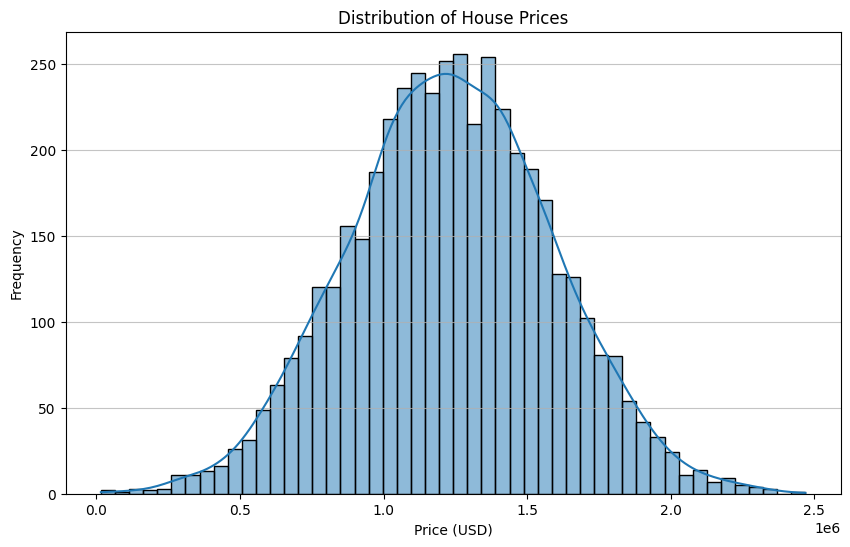

In [ ]:
if df is not None:
    # Price Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Price'], bins=50, kde=True)
    plt.title('Distribution of House Prices')
    plt.xlabel('Price (USD)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


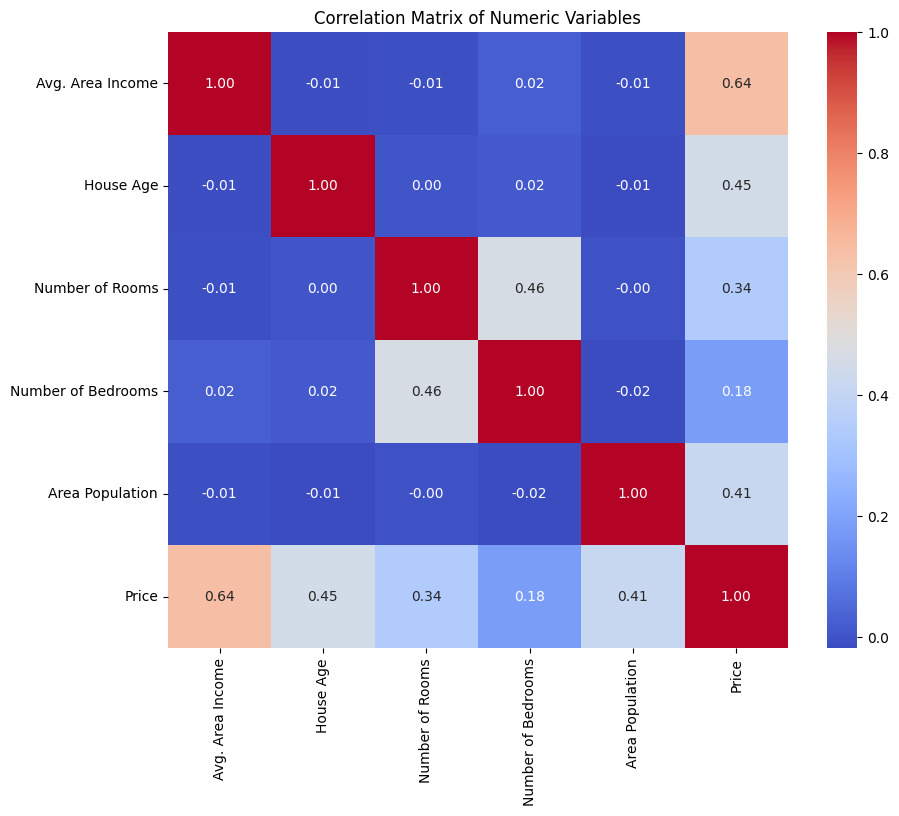

In [ ]:
    # Correlation Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix of Numeric Variables')
    plt.show()

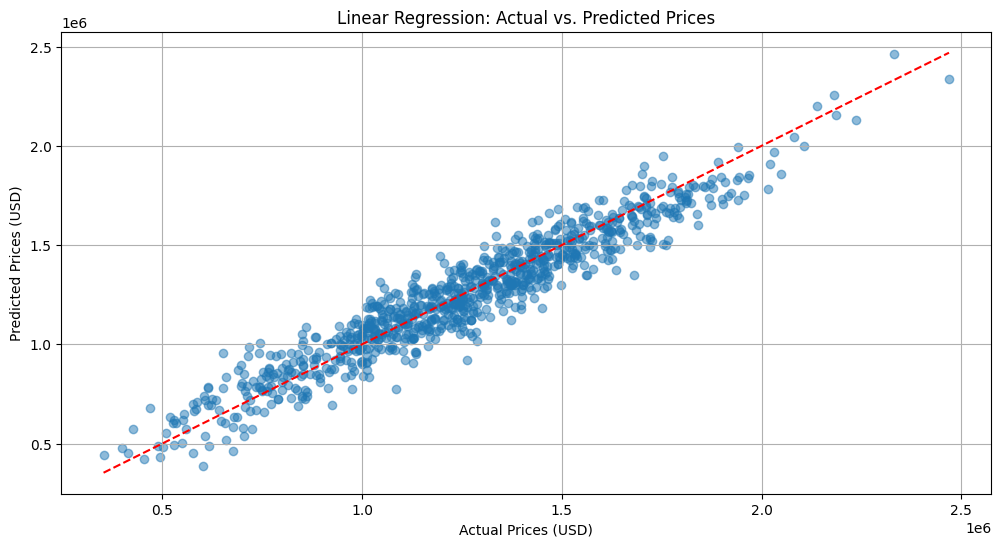

In [ ]:
# Plot of actual vs. predicted values for Linear Regression
plt.figure(figsize=(12, 6))
plt.scatter(y_test, lr_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Prices (USD)')
plt.ylabel('Predicted Prices (USD)')
plt.title('Linear Regression: Actual vs. Predicted Prices')
plt.grid(True)
plt.show()


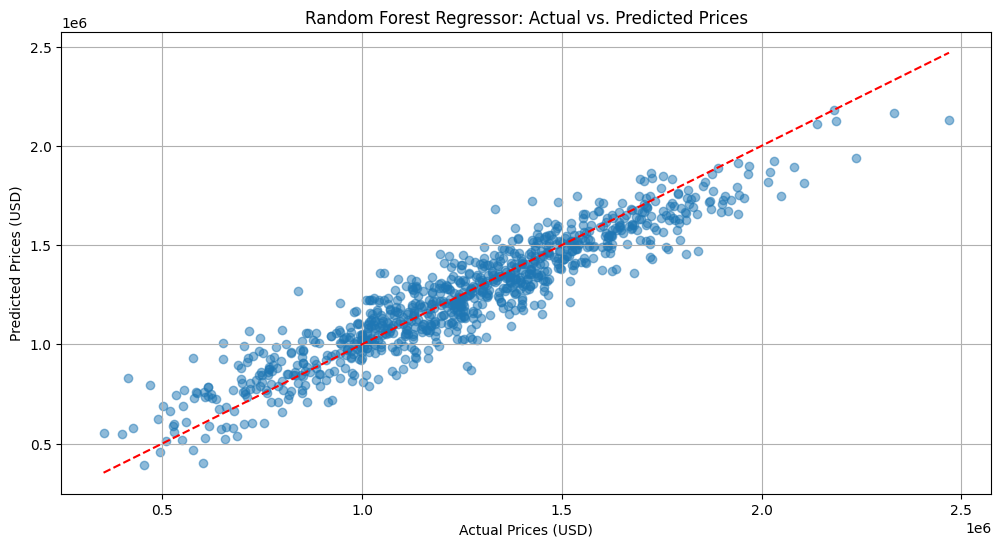

In [ ]:
    # Plot of actual vs. predicted values for Random Forest Regressor
plt.figure(figsize=(12, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Prices (USD)')
plt.ylabel('Predicted Prices (USD)')
plt.title('Random Forest Regressor: Actual vs. Predicted Prices')
plt.grid(True)
plt.show()

### 11. Show Feature Importance for the Random Forest model

This helps us understand which variables most influence price prediction.


--- Feature Importance (Random Forest) ---


,Feature,Importance
0,Avg. Area Income,0.437708
1,House Age,0.228293
4,Area Population,0.194351
2,Number of Rooms,0.119156
3,Number of Bedrooms,0.020492


/tmp/ipykernel_10279/724856434.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


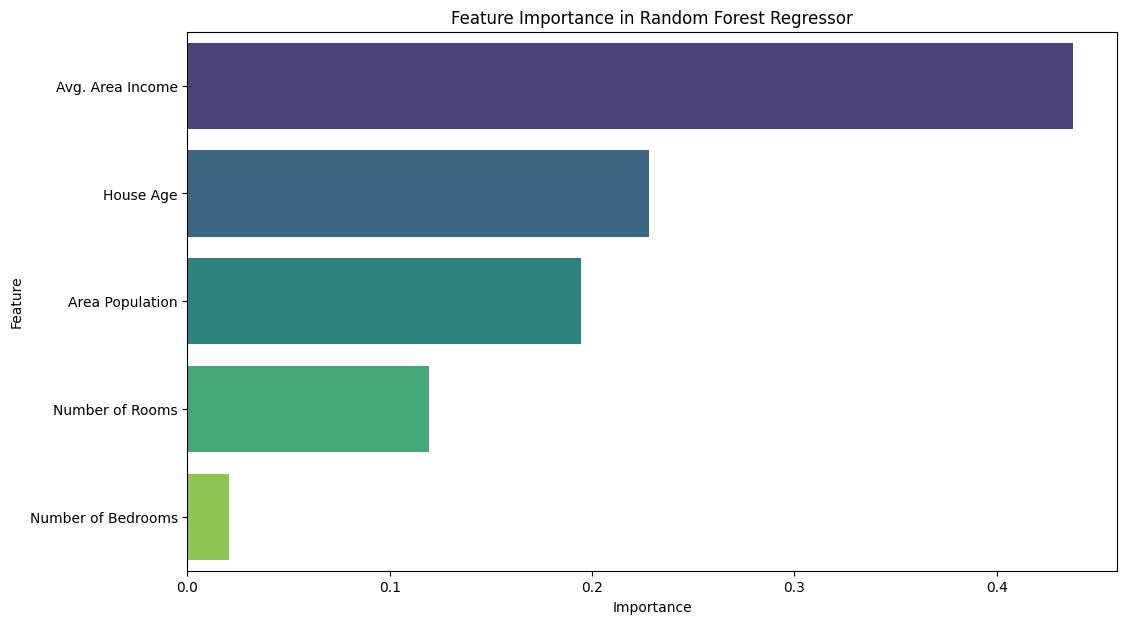

In [ ]:
if df is not None:
    if hasattr(rf_model, 'feature_importances_'):
        feature_importances = pd.DataFrame({
            'Feature': X.columns,
            'Importance': rf_model.feature_importances_
        }).sort_values(by='Importance', ascending=False)

        print("\n--- Feature Importance (Random Forest) ---")
        display(feature_importances)

        plt.figure(figsize=(12, 7))
        sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
        plt.title('Feature Importance in Random Forest Regressor')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    else:
        print("The Random Forest model does not have the feature_importances_ attribute.")

### 12. Make an example prediction using an observation from the test set

In [ ]:
if df is not None:
    # Select a random observation from the test set
    sample_index = np.random.randint(0, len(X_test))
    sample_X = X_test.iloc[[sample_index]]
    sample_y_true = y_test.iloc[[sample_index]]

    # Prediction with the Linear Regression model
    lr_sample_prediction = lr_model.predict(sample_X)

    # Prediction with the Random Forest model
    rf_sample_prediction = rf_model.predict(sample_X)

    print("\n--- Example Prediction ---")
    print(f"Example house features:\n{sample_X}")
    print(f"Actual house price: ${sample_y_true.values[0]:,.2f}")
    print(f"Linear Regression Prediction: ${lr_sample_prediction[0]:,.2f}")
    print(f"Random Forest Prediction: ${rf_sample_prediction[0]:,.2f}")


--- Example Prediction ---
Example house features:
      Avg. Area Income  House Age  Number of Rooms  Number of Bedrooms  \
4299       63582.97606        4.8              5.9                2.16   

      Area Population  
4299            52071  
Actual house price: $1,016,187.10
Linear Regression Prediction: $1,033,728.55
Random Forest Prediction: $1,022,711.50


### Conclusion

This script provides a solid foundation for your house price prediction project, covering everything from data loading to model evaluation and visualization. You can continue experimenting with different models, data preprocessing techniques, or adjust model hyperparameters to improve performance.